In [1]:
# Librairies pour manipulation et visualisation des données
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurations pour les graphiques
%matplotlib inline
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

c:\Users\iadhg\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
!pip install mlflow

In [3]:
# Charger le fichier CSV
df = pd.read_csv("data/public_cars.csv")
df = df.drop(columns=[
    'feature_0','feature_1','feature_2','feature_3','feature_4',
    'feature_5','feature_6','feature_7','feature_8','feature_9'
])

# Afficher les 5 premières lignes
df.head()


,manufacturer_name,model_name,transmission,color,odometer_value,year_produced,engine_fuel,engine_has_gas,engine_type,engine_capacity,body_type,has_warranty,state,drivetrain,duration_listed,price_usd
0,Ford,Fusion,mechanical,blue,245000,2006,gasoline,False,gasoline,1.6,hatchback,False,owned,front,7,4250.0
1,Dodge,Caravan,automatic,silver,265542,2002,gasoline,False,gasoline,3.3,minivan,False,owned,front,133,4000.0
2,Ford,Galaxy,mechanical,blue,168000,2009,diesel,False,diesel,1.8,minivan,False,owned,front,0,10900.0
3,Mazda,6,mechanical,other,225522,2008,gasoline,False,gasoline,1.8,universal,False,owned,front,20,6999.0
4,Audi,80,mechanical,black,370000,1991,gasoline,False,gasoline,1.8,sedan,False,owned,front,160,1600.0


In [4]:
# Taille du dataset
print("Nombre de lignes et colonnes :", df.shape)

df['price_usd'] = df['price_usd'] 

# Informations générales : types de colonnes et non-null
df.info()

# Statistiques descriptives pour les colonnes numériques
df.describe()

Nombre de lignes et colonnes : (30824, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30824 entries, 0 to 30823
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   manufacturer_name  30824 non-null  object 
 1   model_name         30824 non-null  object 
 2   transmission       30824 non-null  object 
 3   color              30824 non-null  object 
 4   odometer_value     30824 non-null  int64  
 5   year_produced      30824 non-null  int64  
 6   engine_fuel        30824 non-null  object 
 7   engine_has_gas     30824 non-null  bool   
 8   engine_type        30824 non-null  object 
 9   engine_capacity    30816 non-null  float64
 10  body_type          30824 non-null  object 
 11  has_warranty       30824 non-null  bool   
 12  state              30824 non-null  object 
 13  drivetrain         30824 non-null  object 
 14  duration_listed    30824 non-null  int64  
 15  price_usd          30824 no

,odometer_value,year_produced,engine_capacity,duration_listed,price_usd
count,30824.000000,30824.000000,30816.000000,30824.000000,30824.000000
mean,248803.130515,2002.939690,2.054232,80.344407,6630.598604
std,135760.720763,8.048786,0.667535,112.656926,6412.213626
min,0.000000,1950.000000,0.200000,0.000000,1.000000
25%,158146.500000,1998.000000,1.600000,23.000000,2145.857500
50%,250000.000000,2003.000000,2.000000,59.000000,4800.000000
75%,325000.000000,2009.000000,2.300000,91.000000,8950.000000
max,1000000.000000,2019.000000,7.500000,2232.000000,50000.000000


In [5]:
# Nombre de valeurs manquantes par colonne
missing_values = df.isnull().sum()
print("Valeurs manquantes par colonne :\n", missing_values)

# Pourcentage de valeurs manquantes
missing_percent = (df.isnull().sum() / len(df)) * 100
print("\nPourcentage de valeurs manquantes par colonne :\n", missing_percent)

Valeurs manquantes par colonne :
 manufacturer_name    0
model_name           0
transmission         0
color                0
odometer_value       0
year_produced        0
engine_fuel          0
engine_has_gas       0
engine_type          0
engine_capacity      8
body_type            0
has_warranty         0
state                0
drivetrain           0
duration_listed      0
price_usd            0
dtype: int64

Pourcentage de valeurs manquantes par colonne :
 manufacturer_name    0.000000
model_name           0.000000
transmission         0.000000
color                0.000000
odometer_value       0.000000
year_produced        0.000000
engine_fuel          0.000000
engine_has_gas       0.000000
engine_type          0.000000
engine_capacity      0.025954
body_type            0.000000
has_warranty         0.000000
state                0.000000
drivetrain           0.000000
duration_listed      0.000000
price_usd            0.000000
dtype: float64


In [6]:
# Nombre de doublons
print("Nombre de lignes dupliquées :", df.duplicated().sum())

Nombre de lignes dupliquées : 38


In [7]:
# Statistiques complètes
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols].agg(['min', 'max', 'mean', 'median', 'std'])

,odometer_value,year_produced,engine_capacity,duration_listed,price_usd
min,0.000000,1950.000000,0.200000,0.000000,1.000000
max,1000000.000000,2019.000000,7.500000,2232.000000,50000.000000
mean,248803.130515,2002.939690,2.054232,80.344407,6630.598604
median,250000.000000,2003.000000,2.000000,59.000000,4800.000000
std,135760.720763,8.048786,0.667535,112.656926,6412.213626


In [8]:


# Supprimer les doublons
df = df.drop_duplicates()

# Remplacer les valeurs manquantes de engine_capacity par la moyenne
df["engine_capacity"] = df["engine_capacity"].fillna(df["engine_capacity"].mean())

# Vérification
print("Nouvelle taille du dataset :", df.shape)
print("Valeurs manquantes :")
print(df.isnull().sum())


Nouvelle taille du dataset : (30786, 16)
Valeurs manquantes :
manufacturer_name    0
model_name           0
transmission         0
color                0
odometer_value       0
year_produced        0
engine_fuel          0
engine_has_gas       0
engine_type          0
engine_capacity      0
body_type            0
has_warranty         0
state                0
drivetrain           0
duration_listed      0
price_usd            0
dtype: int64


In [10]:


# 1. Age de la voiture
df["car_age"] = 2026 - df["year_produced"]

# 2. Kilométrage par an
df["km_per_year"] = df["odometer_value"] / (df["car_age"] + 1)
df['luxury_brand_flag'] = df['manufacturer_name'].isin(['BMW','Mercedes','Audi','Porsche']).astype(int)

# 3. Index puissance moteur
df["engine_power_index"] = df["engine_capacity"] * 100



df.head()

,manufacturer_name,model_name,transmission,color,odometer_value,year_produced,engine_fuel,engine_has_gas,engine_type,engine_capacity,body_type,has_warranty,state,drivetrain,duration_listed,price_usd,car_age,km_per_year,luxury_brand_flag,engine_power_index
0,Ford,Fusion,mechanical,blue,245000,2006,gasoline,False,gasoline,1.6,hatchback,False,owned,front,7,4250.0,20,11666.666667,0,160.0
1,Dodge,Caravan,automatic,silver,265542,2002,gasoline,False,gasoline,3.3,minivan,False,owned,front,133,4000.0,24,10621.680000,0,330.0
2,Ford,Galaxy,mechanical,blue,168000,2009,diesel,False,diesel,1.8,minivan,False,owned,front,0,10900.0,17,9333.333333,0,180.0
3,Mazda,6,mechanical,other,225522,2008,gasoline,False,gasoline,1.8,universal,False,owned,front,20,6999.0,18,11869.578947,0,180.0
4,Audi,80,mechanical,black,370000,1991,gasoline,False,gasoline,1.8,sedan,False,owned,front,160,1600.0,35,10277.777778,1,180.0


c:\Users\iadhg\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


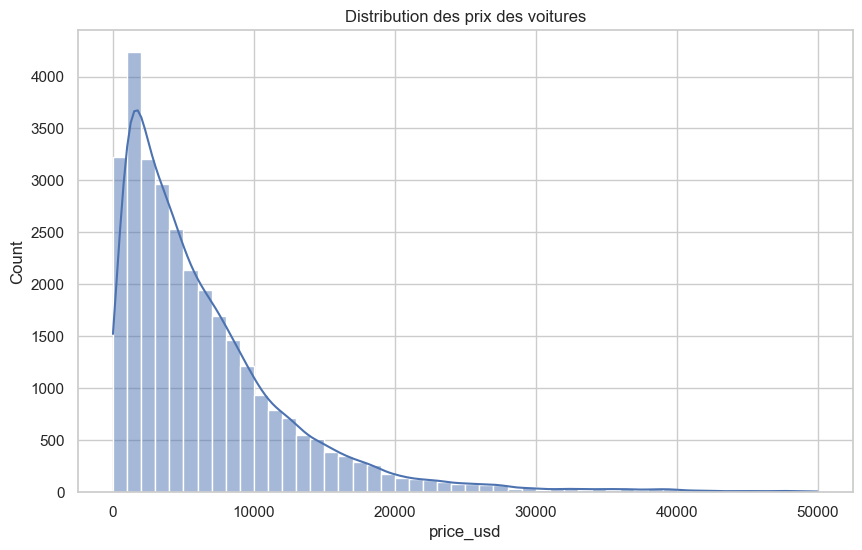

c:\Users\iadhg\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


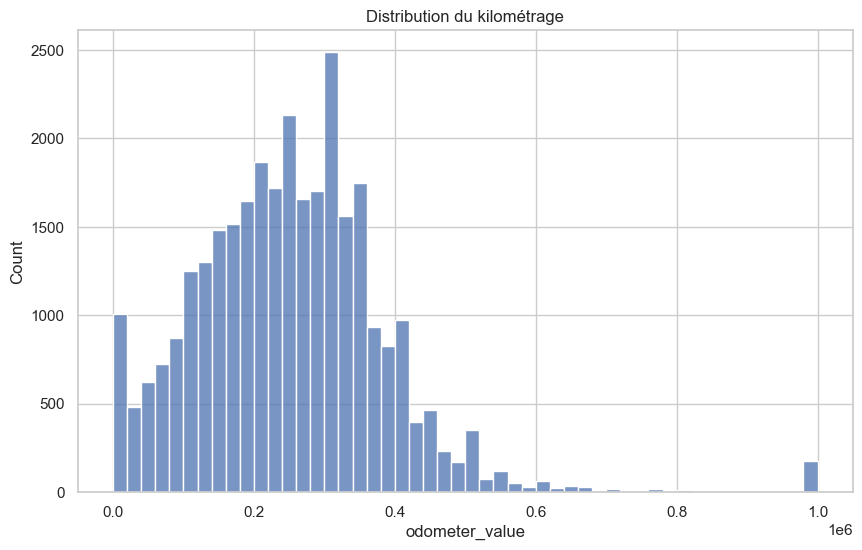

In [11]:
# Distribution du prix
plt.figure()
sns.histplot(df["price_usd"], bins=50, kde=True)
plt.title("Distribution des prix des voitures")
plt.show()

# Distribution kilométrage
plt.figure()
sns.histplot(df["odometer_value"], bins=50)
plt.title("Distribution du kilométrage")
plt.show()

In [13]:
df.to_csv("data/public_cars_clean.csv", index=False)

In [14]:
pip install category_encoders

Note: you may need to restart the kernel to use updated packages.


In [15]:
import pandas as pd
import numpy as np
from category_encoders import TargetEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# ===============================
# 1️⃣ Séparer df avec/sans valeurs aberrantes
# ===============================
numeric_cols = df.select_dtypes(include=np.number).columns

Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

outliers_mask = ((df[numeric_cols] < (Q1 - 1.5*IQR)) | (df[numeric_cols] > (Q3 + 1.5*IQR))).any(axis=1)

df_outliers = df[outliers_mask].copy()  # dataset avec aberrantes
df2 = df[~outliers_mask].copy()          # dataset sans aberrantes

print("Nombre de lignes avec aberrantes :", df_outliers.shape[0])
print("Nombre de lignes sans aberrantes :", df2.shape[0])

# ===============================
# 2️⃣ Log-transform sur les deux datasets
# ===============================
df['log_price'] = np.log1p(df['price_usd'])
df2['log_price'] = np.log1p(df2['price_usd'])

# ===============================
# 3️⃣ Fonction pour encodage train/test
# ===============================
def encode_dataset(dataset, target='log_price'):
    X = dataset.drop(columns=['price_usd', target])
    y = dataset[target]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Target Encoding
    te_cols = ['manufacturer_name','model_name','color','body_type']
    te = TargetEncoder(cols=te_cols)
    X_train_te = te.fit_transform(X_train, y_train)
    X_test_te = te.transform(X_test)

    # One-Hot Encoding
    ohe_cols = ['transmission','engine_fuel','engine_type','state','drivetrain']
    ohe = OneHotEncoder(sparse_output=False, drop='first')  # <-- correction ici
    ohe.fit(X_train_te[ohe_cols])

    ohe_train = pd.DataFrame(ohe.transform(X_train_te[ohe_cols]),
                             columns=ohe.get_feature_names_out(ohe_cols),
                             index=X_train_te.index)
    ohe_test = pd.DataFrame(ohe.transform(X_test_te[ohe_cols]),
                            columns=ohe.get_feature_names_out(ohe_cols),
                            index=X_test_te.index)

    X_train_te = X_train_te.drop(columns=ohe_cols)
    X_test_te = X_test_te.drop(columns=ohe_cols)

    X_train_final = pd.concat([X_train_te, ohe_train], axis=1)
    X_test_final = pd.concat([X_test_te, ohe_test], axis=1)

    return X_train_final, X_test_final, y_train, y_test

# ===============================
# 4️⃣ Encodage pour df (avec aberrantes)
# ===============================
X_train_df, X_test_df, y_train_df, y_test_df = encode_dataset(df)

# ===============================
# 5️⃣ Encodage pour df2 (sans aberrantes)
# ===============================
X_train_df2, X_test_df2, y_train_df2, y_test_df2 = encode_dataset(df2)

# ===============================
# 6️⃣ Corrélation avec log_price
# ===============================
# Pour le train set complet
df_corr_df = pd.concat([X_train_df, y_train_df], axis=1).corr()['log_price'].sort_values(ascending=False)
df_corr_df2 = pd.concat([X_train_df2, y_train_df2], axis=1).corr()['log_price'].sort_values(ascending=False)

print("Top corrélations avec log_price (avec aberrantes) :")
print(df_corr_df.head(10))

print("\nTop corrélations avec log_price (sans aberrantes) :")
print(df_corr_df2.head(10))

Nombre de lignes avec aberrantes : 8879
Nombre de lignes sans aberrantes : 21907
Top corrélations avec log_price (avec aberrantes) :
log_price             1.000000
year_produced         0.811066
model_name            0.737832
manufacturer_name     0.431685
body_type             0.429916
color                 0.362288
engine_power_index    0.295215
engine_capacity       0.295215
state_new             0.176924
has_warranty          0.170146
Name: log_price, dtype: float64

Top corrélations avec log_price (sans aberrantes) :
log_price             1.000000
year_produced         0.830103
model_name            0.713065
body_type             0.382740
manufacturer_name     0.379408
color                 0.354055
state_owned           0.174682
engine_power_index    0.160073
engine_capacity       0.160073
km_per_year           0.126635
Name: log_price, dtype: float64


Nombre de valeurs aberrantes par colonne :
 luxury_brand_flag     4106
duration_listed       2129
engine_capacity       1602
engine_power_index    1602
km_per_year           1410
price_usd             1396
odometer_value         439
year_produced          129
car_age                129
log_price              120
dtype: int64


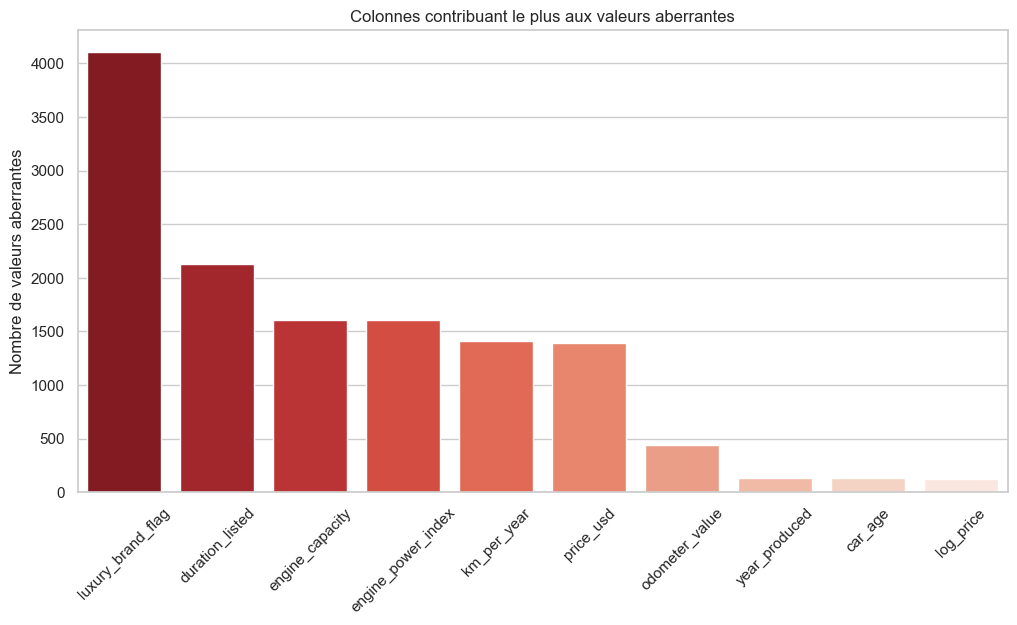

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# 1️⃣ Détection des valeurs aberrantes par colonne
# ===============================
numeric_cols = df.select_dtypes(include=np.number).columns

Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

# Masque booléen pour chaque colonne : True si valeur aberrante
outliers_per_col = ((df[numeric_cols] < (Q1 - 1.5*IQR)) | (df[numeric_cols] > (Q3 + 1.5*IQR)))

# Compter le nombre de valeurs aberrantes par colonne
outliers_count = outliers_per_col.sum().sort_values(ascending=False)
print("Nombre de valeurs aberrantes par colonne :\n", outliers_count)

# ===============================
# 2️⃣ Visualisation avec un barplot
# ===============================
plt.figure(figsize=(12,6))
sns.barplot(x=outliers_count.index, y=outliers_count.values, palette="Reds_r")
plt.xticks(rotation=45)
plt.ylabel("Nombre de valeurs aberrantes")
plt.title("Colonnes contribuant le plus aux valeurs aberrantes")
plt.show()

In [34]:
import time
import psutil
import mlflow
import mlflow.sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

# Définir l'expérience
mlflow.set_experiment("car_price_predection-test-all-algorithms")

# Fonction entraînement + metrics + system metrics
def train_evaluate_rf_with_system(X_train, X_test, y_train, y_test, n_estimators=200, random_state=32):

    rf = RandomForestRegressor(
        n_estimators=n_estimators,
        random_state=random_state,
        n_jobs=-1
    )

    # Log système avant entraînement
    cpu_before = psutil.cpu_percent(interval=1)
    ram_before = psutil.virtual_memory().percent

    start = time.time()
    rf.fit(X_train, y_train)
    end = time.time()

    # Prédiction et métriques
    y_pred = rf.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    training_time = end - start

    # Log système après entraînement
    cpu_after = psutil.cpu_percent(interval=1)
    ram_after = psutil.virtual_memory().percent

    # Metrics MLflow
    mlflow.log_metric("R2", r2)
    mlflow.log_metric("MSE", mse)
    mlflow.log_metric("training_time_sec", training_time)
    mlflow.log_metric("CPU_before", cpu_before)
    mlflow.log_metric("RAM_before", ram_before)
    mlflow.log_metric("CPU_after", cpu_after)
    mlflow.log_metric("RAM_after", ram_after)

    return rf, r2, mse

# ===============================
# RUN 1 : Dataset avec aberrantes
# ===============================
with mlflow.start_run(run_name="RF_with_outliers_system"):

    rf, r2_df, mse_df = train_evaluate_rf_with_system(
        X_train_df, X_test_df,
        y_train_df, y_test_df
    )

    # log paramètres
    mlflow.log_param("model", "RandomForest")
    mlflow.log_param("n_estimators", 300)
    mlflow.log_param("dataset", "with_outliers")

    # sauvegarder le modèle
    mlflow.sklearn.log_model(rf, "rf_model")

    print(f"Random Forest (avec aberrantes) → R²: {r2_df:.4f}, MSE: {mse_df:.4f}")

# ===============================
# RUN 2 : Dataset sans aberrantes
# ===============================
with mlflow.start_run(run_name="RF_without_outliers_system"):

    rf2, r2_df2, mse_df2 = train_evaluate_rf_with_system(
        X_train_df2, X_test_df2,
        y_train_df2, y_test_df2
    )

    mlflow.log_param("model", "RandomForest")
    mlflow.log_param("n_estimators", 300)
    mlflow.log_param("dataset", "without_outliers")

    mlflow.sklearn.log_model(rf2, "rf_model")

    print(f"Random Forest (sans aberrantes) → R²: {r2_df2:.4f}, MSE: {mse_df2:.4f}")

2026/03/12 11:36:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/12 11:36:07 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Random Forest (avec aberrantes) → R²: 0.8894, MSE: 0.1165


2026/03/12 11:36:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/12 11:36:19 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Random Forest (sans aberrantes) → R²: 0.8826, MSE: 0.1052


In [35]:
import time
import psutil
import mlflow
import mlflow.sklearn
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error

# Définir l'expérience MLflow
mlflow.set_experiment("car_price_predection-test-all-algorithms")

# ===============================
# Fonction entraînement Linear Regression + metrics + system metrics
# ===============================
def train_evaluate_lr_with_system(X_train, X_test, y_train, y_test):

    # Pipeline StandardScaler + LinearRegression
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ])

    # Log système avant entraînement
    cpu_before = psutil.cpu_percent(interval=1)
    ram_before = psutil.virtual_memory().percent

    start = time.time()
    pipeline.fit(X_train, y_train)
    end = time.time()

    # Prédiction et métriques
    y_pred = pipeline.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    training_time = end - start

    # Log système après entraînement
    cpu_after = psutil.cpu_percent(interval=1)
    ram_after = psutil.virtual_memory().percent

    # Log metrics dans MLflow
    mlflow.log_metric("R2", r2)
    mlflow.log_metric("MSE", mse)
    mlflow.log_metric("training_time_sec", training_time)
    mlflow.log_metric("CPU_before", cpu_before)
    mlflow.log_metric("RAM_before", ram_before)
    mlflow.log_metric("CPU_after", cpu_after)
    mlflow.log_metric("RAM_after", ram_after)

    return pipeline, r2, mse

# ===============================
# RUN 1 : Dataset avec aberrantes
# ===============================
with mlflow.start_run(run_name="LR_with_outliers_system"):

    lr, r2_df, mse_df = train_evaluate_lr_with_system(
        X_train_df, X_test_df,
        y_train_df, y_test_df
    )

    # log paramètres
    mlflow.log_param("model", "LinearRegression")
    mlflow.log_param("pipeline", "StandardScaler + LinearRegression")
    mlflow.log_param("dataset", "with_outliers")

    # sauvegarder le modèle
    mlflow.sklearn.log_model(lr, "lr_model")

    print(f"Linear Regression (avec aberrantes) → R²: {r2_df:.4f}, MSE: {mse_df:.4f}")

# ===============================
# RUN 2 : Dataset sans aberrantes
# ===============================
with mlflow.start_run(run_name="LR_without_outliers_system"):

    lr2, r2_df2, mse_df2 = train_evaluate_lr_with_system(
        X_train_df2, X_test_df2,
        y_train_df2, y_test_df2
    )

    mlflow.log_param("model", "LinearRegression")
    mlflow.log_param("pipeline", "StandardScaler + LinearRegression")
    mlflow.log_param("dataset", "without_outliers")

    mlflow.sklearn.log_model(lr2, "lr_model")

    print(f"Linear Regression (sans aberrantes) → R²: {r2_df2:.4f}, MSE: {mse_df2:.4f}")

2026/03/12 11:44:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/12 11:44:46 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Linear Regression (avec aberrantes) → R²: 0.8288, MSE: 0.1803


2026/03/12 11:44:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/12 11:44:54 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Linear Regression (sans aberrantes) → R²: 0.8284, MSE: 0.1538


In [43]:
import time
import psutil
import mlflow
import mlflow.sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error
from xgboost import XGBRegressor

# Définir l'expérience MLflow
mlflow.set_experiment("car_price_predection-test-all-algorithms")

# ===============================
# Fonction entraînement XGBoost + metrics + system metrics
# ===============================
def train_evaluate_xgb_with_system(X_train, X_test, y_train, y_test):

    # Hyperparamètres XGBoost
    xgb_params = {
        "n_estimators": 200,
        "learning_rate": 0.01,
        "max_depth": 6,
        "subsample": 0.9,
        "colsample_bytree": 0.9,
        "random_state": 42
    }

    # Pipeline StandardScaler + XGBRegressor
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", XGBRegressor(**xgb_params))
    ])

    # Log système avant entraînement
    cpu_before = psutil.cpu_percent(interval=1)
    ram_before = psutil.virtual_memory().percent

    start = time.time()
    pipeline.fit(X_train, y_train)
    end = time.time()

    # Prédiction et métriques
    y_pred = pipeline.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    training_time = end - start

    # Log système après entraînement
    cpu_after = psutil.cpu_percent(interval=1)
    ram_after = psutil.virtual_memory().percent

    # Log metrics dans MLflow
    mlflow.log_metric("R2", r2)
    mlflow.log_metric("MSE", mse)
    mlflow.log_metric("training_time_sec", training_time)
    mlflow.log_metric("CPU_before", cpu_before)
    mlflow.log_metric("RAM_before", ram_before)
    mlflow.log_metric("CPU_after", cpu_after)
    mlflow.log_metric("RAM_after", ram_after)

    return pipeline, r2, mse, xgb_params

# ===============================
# RUN 1 : Dataset avec aberrantes
# ===============================
with mlflow.start_run(run_name="XGB_with_outliers_system"):

    xgb_model, r2_df, mse_df, params = train_evaluate_xgb_with_system(
        X_train_df, X_test_df,
        y_train_df, y_test_df
    )

    # log paramètres XGBoost
    mlflow.log_param("model", "XGBoost")
    mlflow.log_param("dataset", "with_outliers")
    for key, value in params.items():
        mlflow.log_param(key, value)

    # sauvegarder le pipeline complet
    mlflow.sklearn.log_model(xgb_model, "xgb_pipeline_model")

    print(f"XGBoost (avec aberrantes) → R²: {r2_df:.4f}, MSE: {mse_df:.4f}")

# ===============================
# RUN 2 : Dataset sans aberrantes
# ===============================
with mlflow.start_run(run_name="XGB_without_outliers_system"):

    xgb_model2, r2_df2, mse_df2, params2 = train_evaluate_xgb_with_system(
        X_train_df2, X_test_df2,
        y_train_df2, y_test_df2
    )

    mlflow.log_param("model", "XGBoost")
    mlflow.log_param("dataset", "without_outliers")
    for key, value in params2.items():
        mlflow.log_param(key, value)

    mlflow.sklearn.log_model(xgb_model2, "xgb_pipeline_model")

    print(f"XGBoost (sans aberrantes) → R²: {r2_df2:.4f}, MSE: {mse_df2:.4f}")

2026/03/12 12:00:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/12 12:00:39 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


XGBoost (avec aberrantes) → R²: 0.8549, MSE: 0.1528


2026/03/12 12:00:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/12 12:00:46 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


XGBoost (sans aberrantes) → R²: 0.8501, MSE: 0.1344


In [51]:
import time
import psutil
import mlflow
import mlflow.sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.neighbors import KNeighborsRegressor

# Définir l'expérience MLflow
mlflow.set_experiment("car_price_predection-test-all-algorithms")

# ===============================
# Fonction entraînement KNN 
# ===============================
def train_evaluate_knn_with_system(X_train, X_test, y_train, y_test, n_neighbors=5):

    # Pipeline StandardScaler + KNN
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsRegressor(n_neighbors=n_neighbors))
    ])

    # Log système avant entraînement
    cpu_before = psutil.cpu_percent(interval=1)
    ram_before = psutil.virtual_memory().percent

    start = time.time()
    pipeline.fit(X_train, y_train)
    end = time.time()

    # Prédiction et métriques
    y_pred = pipeline.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    training_time = end - start

    # Log système après entraînement
    cpu_after = psutil.cpu_percent(interval=1)
    ram_after = psutil.virtual_memory().percent

    # Log metrics MLflow
    mlflow.log_metric("R2", r2)
    mlflow.log_metric("MSE", mse)
    mlflow.log_metric("training_time_sec", training_time)
    mlflow.log_metric("CPU_before", cpu_before)
    mlflow.log_metric("RAM_before", ram_before)
    mlflow.log_metric("CPU_after", cpu_after)
    mlflow.log_metric("RAM_after", ram_after)

    # Hyperparamètres pour versioning
    knn_params = {"n_neighbors": n_neighbors}

    return pipeline, r2, mse, knn_params

# ===============================
# RUN 1 : Dataset avec aberrantes
# ===============================
with mlflow.start_run(run_name="KNN_with_outliers_system"):

    knn_model, r2_df, mse_df, params = train_evaluate_knn_with_system(
        X_train_df, X_test_df,
        y_train_df, y_test_df,
        n_neighbors=10
    )

    # log paramètres
    mlflow.log_param("model", "KNN")
    mlflow.log_param("dataset", "with_outliers")
    for key, value in params.items():
        mlflow.log_param(key, value)

    # sauvegarder le pipeline complet
    mlflow.sklearn.log_model(knn_model, "knn_pipeline_model")

    print(f"KNN (avec aberrantes) → R²: {r2_df:.4f}, MSE: {mse_df:.4f}")

# ===============================
# RUN 2 : Dataset sans aberrantes
# ===============================
with mlflow.start_run(run_name="KNN_without_outliers_system"):

    knn_model2, r2_df2, mse_df2, params2 = train_evaluate_knn_with_system(
        X_train_df2, X_test_df2,
        y_train_df2, y_test_df2,
        n_neighbors=10
    )

    mlflow.log_param("model", "KNN")
    mlflow.log_param("dataset", "without_outliers")
    for key, value in params2.items():
        mlflow.log_param(key, value)

    mlflow.sklearn.log_model(knn_model2, "knn_pipeline_model")

    print(f"KNN (sans aberrantes) → R²: {r2_df2:.4f}, MSE: {mse_df2:.4f}")

2026/03/12 12:28:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/12 12:28:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


KNN (avec aberrantes) → R²: 0.8488, MSE: 0.1592


2026/03/12 12:28:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/12 12:28:10 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


KNN (sans aberrantes) → R²: 0.8322, MSE: 0.1504
